This notebook contains code to compute TF sensitive peaks and genes. 

Install packages

In [1]:
#install.packages("PMA")
#install.packages("protoclust")

In [2]:
#BiocManager::install("glmGamPoi")

Load libraries

In [3]:
options(Seurat.object.assay.version = 'v3') 
library(dplyr)
library(Seurat)
library(ggridges)
library(ggplot2)



Attaching package: ‘dplyr’


The following objects are masked from ‘package:stats’:

    filter, lag


The following objects are masked from ‘package:base’:

    intersect, setdiff, setequal, union


Loading required package: SeuratObject

Loading required package: sp


Attaching package: ‘SeuratObject’


The following object is masked from ‘package:base’:

    intersect




# Identify TF-sensitive ACRs (ATAC-seq)

In [4]:
JAN_028_combined=readRDS("~/github_reproducibility/merged_seurat_object_step2_all_reps.RDS")


In [5]:
JAN_028_combined=JAN_028_combined[,row.names(JAN_028_combined@meta.data %>%
filter(replicate != 'rep11')%>%
filter(replicate != 'rep15'))]

Loading required package: Signac



In [6]:
library(dplyr)

JAN_028_combined@meta.data=JAN_028_combined@meta.data %>%
  mutate(rep_info = gsub("(.+)_.*", "\\1", row.names(JAN_028_combined@meta.data))) 


In [7]:
JAN_028_combined_filtered=CreateSeuratObject(JAN_028_combined@assays$ATAC@counts,assay='ATAC')

In [8]:
DefaultAssay(JAN_028_combined_filtered)='ATAC'
JAN_028_combined_filtered <- RunTFIDF(JAN_028_combined_filtered)
JAN_028_combined_filtered <- FindTopFeatures(JAN_028_combined_filtered, min.cutoff = 'q0')
JAN_028_combined_filtered <- RunSVD(JAN_028_combined_filtered)

Performing TF-IDF normalization

Running SVD

Scaling cell embeddings



In [9]:
JAN_028_combined_filtered <- RunUMAP(object = JAN_028_combined_filtered, reduction = 'lsi', dims = 2:30)
JAN_028_combined_filtered <- FindNeighbors(object = JAN_028_combined_filtered, reduction = 'lsi', dims = 2:30)
JAN_028_combined_filtered <- FindClusters(object = JAN_028_combined_filtered, verbose = FALSE, algorithm = 3)


Warning message:
“The default method for RunUMAP has changed from calling Python UMAP via reticulate to the R-native UWOT using the cosine metric
To use Python UMAP via reticulate, set umap.method to 'umap-learn' and metric to 'correlation'
This message will be shown once per session”
21:11:53 UMAP embedding parameters a = 0.9922 b = 1.112

Found more than one class "dist" in cache; using the first, from namespace 'spam'

Also defined by ‘BiocGenerics’

21:11:53 Read 137604 rows and found 29 numeric columns

21:11:53 Using Annoy for neighbor search, n_neighbors = 30

Found more than one class "dist" in cache; using the first, from namespace 'spam'

Also defined by ‘BiocGenerics’

21:11:53 Building Annoy index with metric = cosine, n_trees = 50

0%   10   20   30   40   50   60   70   80   90   100%

[----|----|----|----|----|----|----|----|----|----|

*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
|

21:12:20 Writing NN index file to

In [14]:
seurat_obj_mixscale_separate_guides_AAVS1_1_reference_ATAC=JAN_028_combined_filtered



In [15]:
#saveRDS(seurat_obj_mixscale_separate_guides_AAVS1_1_reference_ATAC, "~/github_reproducibility/merged_seurat_object_step2_all_reps_with_LSI.RDS")



It is absolutely essential to run FindVariableFeatures before, otherwise it will unavoidably crash, because this by default computes the PRTB signature for all features

In [16]:
seurat_obj_mixscale_separate_guides_AAVS1_1_reference_ATAC=FindVariableFeatures(seurat_obj_mixscale_separate_guides_AAVS1_1_reference_ATAC,nfeatures = 20000)



In [51]:
JAN_028_combined@meta.data$cell_id=row.names(JAN_028_combined@meta.data)
seurat_obj_mixscale_separate_guides_AAVS1_1_reference_ATAC@meta.data$cell_id=row.names(seurat_obj_mixscale_separate_guides_AAVS1_1_reference_ATAC@meta.data)

temp_meta.data=merge(seurat_obj_mixscale_separate_guides_AAVS1_1_reference_ATAC@meta.data,JAN_028_combined@meta.data[,c("cell_id","perturbation_name")],by='cell_id')
temp_meta.data=temp_meta.data%>%
  mutate(orig.ident = factor(orig.ident, levels = paste0("rep", 1:16)))
temp_meta.data <- temp_meta.data %>%
  arrange(orig.ident)
seurat_obj_mixscale_separate_guides_AAVS1_1_reference_ATAC@meta.data$perturbation_name = temp_meta.data$perturbation_name



In [54]:
# calculate Perturbation signatures 
seurat_obj_mixscale_separate_guides_AAVS1_1_reference_ATAC <- CalcPerturbSig(
    object = seurat_obj_mixscale_separate_guides_AAVS1_1_reference_ATAC, 
    assay = "ATAC", 
    slot = "data", 
    gd.class ="perturbation_name", 
    nt.cell.class = "AAVS1_1", 
    reduction = "lsi", 
    ndims = 30, 
    num.neighbors = 20, 
    new.assay.name = "PRTB",verbose=TRUE)

Processing rep1

Warning message in asMethod(object):
“sparse->dense coercion: allocating vector of size 20.5 GiB”


In [55]:
seurat_obj_mixscale_separate_guides_AAVS1_1_reference_ATAC=ScaleData(seurat_obj_mixscale_separate_guides_AAVS1_1_reference_ATAC)




Centering and scaling data matrix



In [56]:
seurat_obj_mixscale_separate_guides_AAVS1_1_reference_ATAC@meta.data$guide_ID=seurat_obj_mixscale_separate_guides_AAVS1_1_reference_ATAC@meta.data$perturbation_name


Install modified github branch of mixscale for perturbation score computation on ATAC. To do so, modify scoring_de.R so that all mentions to RNA are replaced by ATAC (e.g. nCount_RNA becomes nCount_ATAC, assay = 'RNA' becomes assay = 'ATAC') and so forth. Modify visualization.R in the same fashion.

In [ ]:
#detach("package:Mixscale", unload=TRUE)


In [57]:
devtools::install_github("",auth_token = '')


── R CMD build ─────────────────────────────────────────────────────────────────
* checking for file ‘/tmp/RtmpGPAVW8/remotes25235f7b2b5/gighuarhguggg45-mixscale_private-24d9ea727f7e8e05380e3d486c3bdce3e58740c0/DESCRIPTION’ ... OK
* preparing ‘Mixscale’:
* checking DESCRIPTION meta-information ... OK
* checking for LF line-endings in source and make files and shell scripts
* checking for empty or unneeded directories
* building ‘Mixscale_0.3.0.tar.gz’



Installing package into ‘/home/jupyter/packages’
(as ‘lib’ is unspecified)



In [58]:
library(Mixscale)

In [59]:
temp_meta.data=NULL
temp_meta.data=merge(seurat_obj_mixscale_separate_guides_AAVS1_1_reference_ATAC@meta.data,JAN_028_combined@meta.data[,c("cell_id","target")],by='cell_id')
temp_meta.data=temp_meta.data%>%
  mutate(orig.ident = factor(orig.ident, levels = paste0("rep", 1:16)))
temp_meta.data <- temp_meta.data %>%
  arrange(orig.ident)
seurat_obj_mixscale_separate_guides_AAVS1_1_reference_ATAC@meta.data$target = temp_meta.data$target



In [65]:
seurat_obj_mixscale_separate_guides_AAVS1_1_reference_ATAC@meta.data$gene=seurat_obj_mixscale_separate_guides_AAVS1_1_reference_ATAC@meta.data$target

In [71]:
seurat_obj_mixscale_separate_guides_AAVS1_1_reference_ATAC = RunMixscale(
    object = seurat_obj_mixscale_separate_guides_AAVS1_1_reference_ATAC, 
    assay = "PRTB", 
    slot = "scale.data", 
    labels = "gene", 
    nt.class.name = "NT", 
    min.de.genes = 0, 
    logfc.threshold = 0,
    de.assay = "ATAC",
    max.de.genes = 100, 
    new.class.name = "mixscale_score", 
    fine.mode = TRUE, 
    verbose = TRUE)

Calculating Mixscale scores ...

Processing KLF1

Finding new perturbation gene set

Finding new perturbation gene set

Finding new perturbation gene set

The number of de.genes ( 378 ) is larger than max.de.genes ( 100 ). Restricting to top 100 genes...

Done with extracting top DE genes for KLF1

Processing TAL1

Finding new perturbation gene set

Finding new perturbation gene set

Finding new perturbation gene set

The number of de.genes ( 1666 ) is larger than max.de.genes ( 100 ). Restricting to top 100 genes...

Done with extracting top DE genes for TAL1

Processing MYB

Finding new perturbation gene set

Finding new perturbation gene set

Finding new perturbation gene set

The number of de.genes ( 236 ) is larger than max.de.genes ( 100 ). Restricting to top 100 genes...

Done with extracting top DE genes for MYB

Processing PRDM16

Finding new perturbation gene set

Finding new perturbation gene set

Finding new perturbation gene set

The number of de.genes ( 1 ) is less than m

Calculating the overall PRTB score...


Done calculating LOO PRTB score for 100 genes in con1...


  TAL1



Calculating the overall PRTB score...


Done calculating LOO PRTB score for 100 genes in con1...


  MYB



Calculating the overall PRTB score...


Done calculating LOO PRTB score for 100 genes in con1...


  PRDM16



Calculating the overall PRTB score...


Done calculating LOO PRTB score for 1 genes in con1...


  IRF9



Calculating the overall PRTB score...


Done calculating LOO PRTB score for 2 genes in con1...


  FOSL1



Calculating the overall PRTB score...


Done calculating LOO PRTB score for 13 genes in con1...


  GATA1



Calculating the overall PRTB score...


Done calculating LOO PRTB score for 100 genes in con1...


  LMO2



Calculating the overall PRTB score...


Done calculating LOO PRTB score for 100 genes in con1...


  GFI1B



Calculating the overall PRTB score...


Done calculating LOO PRTB score for 100 genes in con1...


  IRF1



Calculating the overall PRTB score...


Done calculating LOO PRTB score for 1 genes in con1...


  BCL11A



Calculating the overall PRTB score...


Done calculating LOO PRTB score for 28 genes in con1...


  LDB1



Calculating the overall PRTB score...


Done calculating LOO PRTB score for 100 genes in con1...


  RUNX1



Calculating the overall PRTB score...


Done calculating LOO PRTB score for 100 genes in con1...


  ATF4



Calculating the overall PRTB score...


Done calculating LOO PRTB score for 2 genes in con1...


  NFE2



Calculating the overall PRTB score...


Done calculating LOO PRTB score for 100 genes in con1...


  SNAI2



Calculating the overall PRTB score...


Done calculating LOO PRTB score for 1 genes in con1...


  SPI1



Calculating the overall PRTB score...


Done calculating LOO PRTB score for 4 genes in con1...


  SOX12



Calculating the overall PRTB score...


Done calculating LOO PRTB score for 1 genes in con1...


  GATA2



Calculating the overall PRTB score...


Done calculating LOO PRTB score for 15 genes in con1...


Done with calculating scores for con1



In [74]:
figure_name="JAN_028_mixscale_score_ATAC.pdf"

width = 9.28
height = 40
options(repr.plot.width = width, repr.plot.height = height, repr.plot.res = 600)

# libraries
library(ggridges)
library(ggplot2)
library(viridis)
library(dplyr) 

data <- seurat_obj_mixscale_separate_guides_AAVS1_1_reference_ATAC@meta.data

# Define CONTROLS
special_groups <- c("AAVS1_1", "AAVS1_2", "AAVS1_3", "NT_1", "NT_2", "NT_3")

regular_data <- data[!data$perturbation_name %in% special_groups, ]

average_scores <- regular_data %>%
  group_by(perturbation_name) %>%
  summarize(average_score = mean(mixscale_score, na.rm = TRUE)) %>%
  ungroup() %>%
  arrange(average_score)  

color_values <- viridis(n = nrow(average_scores))
color_values[average_scores$average_score == 0] <- "#440154FF"  

colors <- setNames(color_values, average_scores$perturbation_name)
colors[special_groups] <- "grey"

data$color_group <- ifelse(data$perturbation_name %in% special_groups, "Special", as.character(data$perturbation_name))
ordered_names_RNA=
c('AAVS1_1','AAVS1_2','AAVS1_3','NT_1','NT_2','NT_3','PRDM16_204','PRDM16_379','SNAI2_80','SNAI2_523','LDB1_732','PRDM16_1182','IRF1_199','IRF1_241','IRF1_170','SOX12_162','SNAI2_167','GATA2_752','ATF4_406','SOX12_310','KLF1_395','LDB1_141','IRF9_325','IRF9_81','FOSL1_106','ATF4_343','LMO2_351','SPI1_69','FOSL1_346','SPI1_295','IRF9_111','SOX12_268','ATF4_566','GATA2_176','TAL1_536','SPI1_140','LMO2_428','GFI1B_526','FOSL1_397','GATA2_562','BCL11A_686','MYB_339','BCL11A_476','LMO2_459','BCL11A_752','GATA1_187','RUNX1_844','GFI1B_140','GFI1B_413','GATA1_261','MYB_518','TAL1_556','MYB_136','KLF1_347','TAL1_523','LDB1_265','NFE2_533','GATA1_674','NFE2_682','KLF1_636','NFE2_288','RUNX1_615','RUNX1_312')
ordered_names <- ordered_names_RNA
data$perturbation_name_sorted <- factor(data$perturbation_name, levels = ordered_names)

ggplot(data, aes(x = mixscale_score, y = perturbation_name_sorted, fill = color_group)) +
  geom_density_ridges(alpha = 0.8, scale = 3) +
  scale_fill_manual(values = colors) +
  theme(
    legend.position = "none",
    panel.spacing = unit(0.1, "lines"),
    strip.text.x = element_text(size = 8)
  )+
  theme_minimal() +
  theme(
    text = element_text(size = 16),
    axis.title.y = element_blank(),
          axis.title.x = element_text(size = 22,margin = unit(c(0, 4, 0, 0), "mm")),
      axis.ticks = element_line(size = .6),
      axis.ticks.length=unit(0.06,"inch"),
    axis.text.x = element_text(angle = 0, hjust = 0.5, vjust = 0, size = 22,color='black'),
    axis.text.y = element_text(size = 22,color='black'),
    panel.background = element_blank(),
    panel.grid.major = element_blank(),
    panel.grid.minor = element_blank(),
    axis.line = element_line(color = "black",size = .6),
    strip.text = element_text(size = 16),
      legend.key.size = unit(1, 'cm'),
      legend.text=element_text(size=22),
      legend.title=element_text(size=22),
    strip.background = element_blank()
  )+ theme(legend.position="none")+xlim(-2.5,6)


#ggsave(paste(output_folder,figure_name,sep=""),dpi = 600, width = width, height = height)



Warning message:
“The `size` argument of `element_line()` is deprecated as of ggplot2 3.4.0.
ℹ Please use the `linewidth` argument instead.”
Picking joint bandwidth of 0.183

Warning message:
“Removed 725 rows containing non-finite outside the scale range
(`stat_density_ridges()`).”


In [ ]:
#saveRDS(seurat_obj_mixscale_separate_guides_AAVS1_1_reference_ATAC,"~/github_reproducibility/seurat_obj_mixscale_separate_guides_AAVS1_1_reference_ATAC.RDS")



Copy this object to the bucket and run the WDL for ATAC

Figure 2A left:

In [75]:
output_folder='~/0_perturb_multiome_manuscript_figures/'

In [91]:
JAN_032_RBC_B_perturbation_ratios=read.table("~/JAN_032/JAN_032_genotyping_mission_bio.csv", header=TRUE)
colnames(JAN_032_RBC_B_perturbation_ratios)[1]='complete_name'
colnames(JAN_032_RBC_B_perturbation_ratios)[5]='percent_cells'

data_efficiencies=JAN_032_RBC_B_perturbation_ratios %>%
mutate(complete_name= gsub("sg","",complete_name))%>%
filter(Type == 'Edited')
head(data_efficiencies)


,complete_name,Type,Count,Total,percent_cells
,<chr>,<chr>,<int>,<int>,<dbl>
1,AAVS1_2198,Edited,9,15,0.60000000
4,AAVS1_74,Edited,2,4,0.50000000
6,ATF4_343,Edited,1,43,0.02325581
8,ATF4_406,Edited,14,103,0.13592233
10,ATF4_566,Edited,17,31,0.54838710
12,BCL11A_476,Edited,60,76,0.78947368


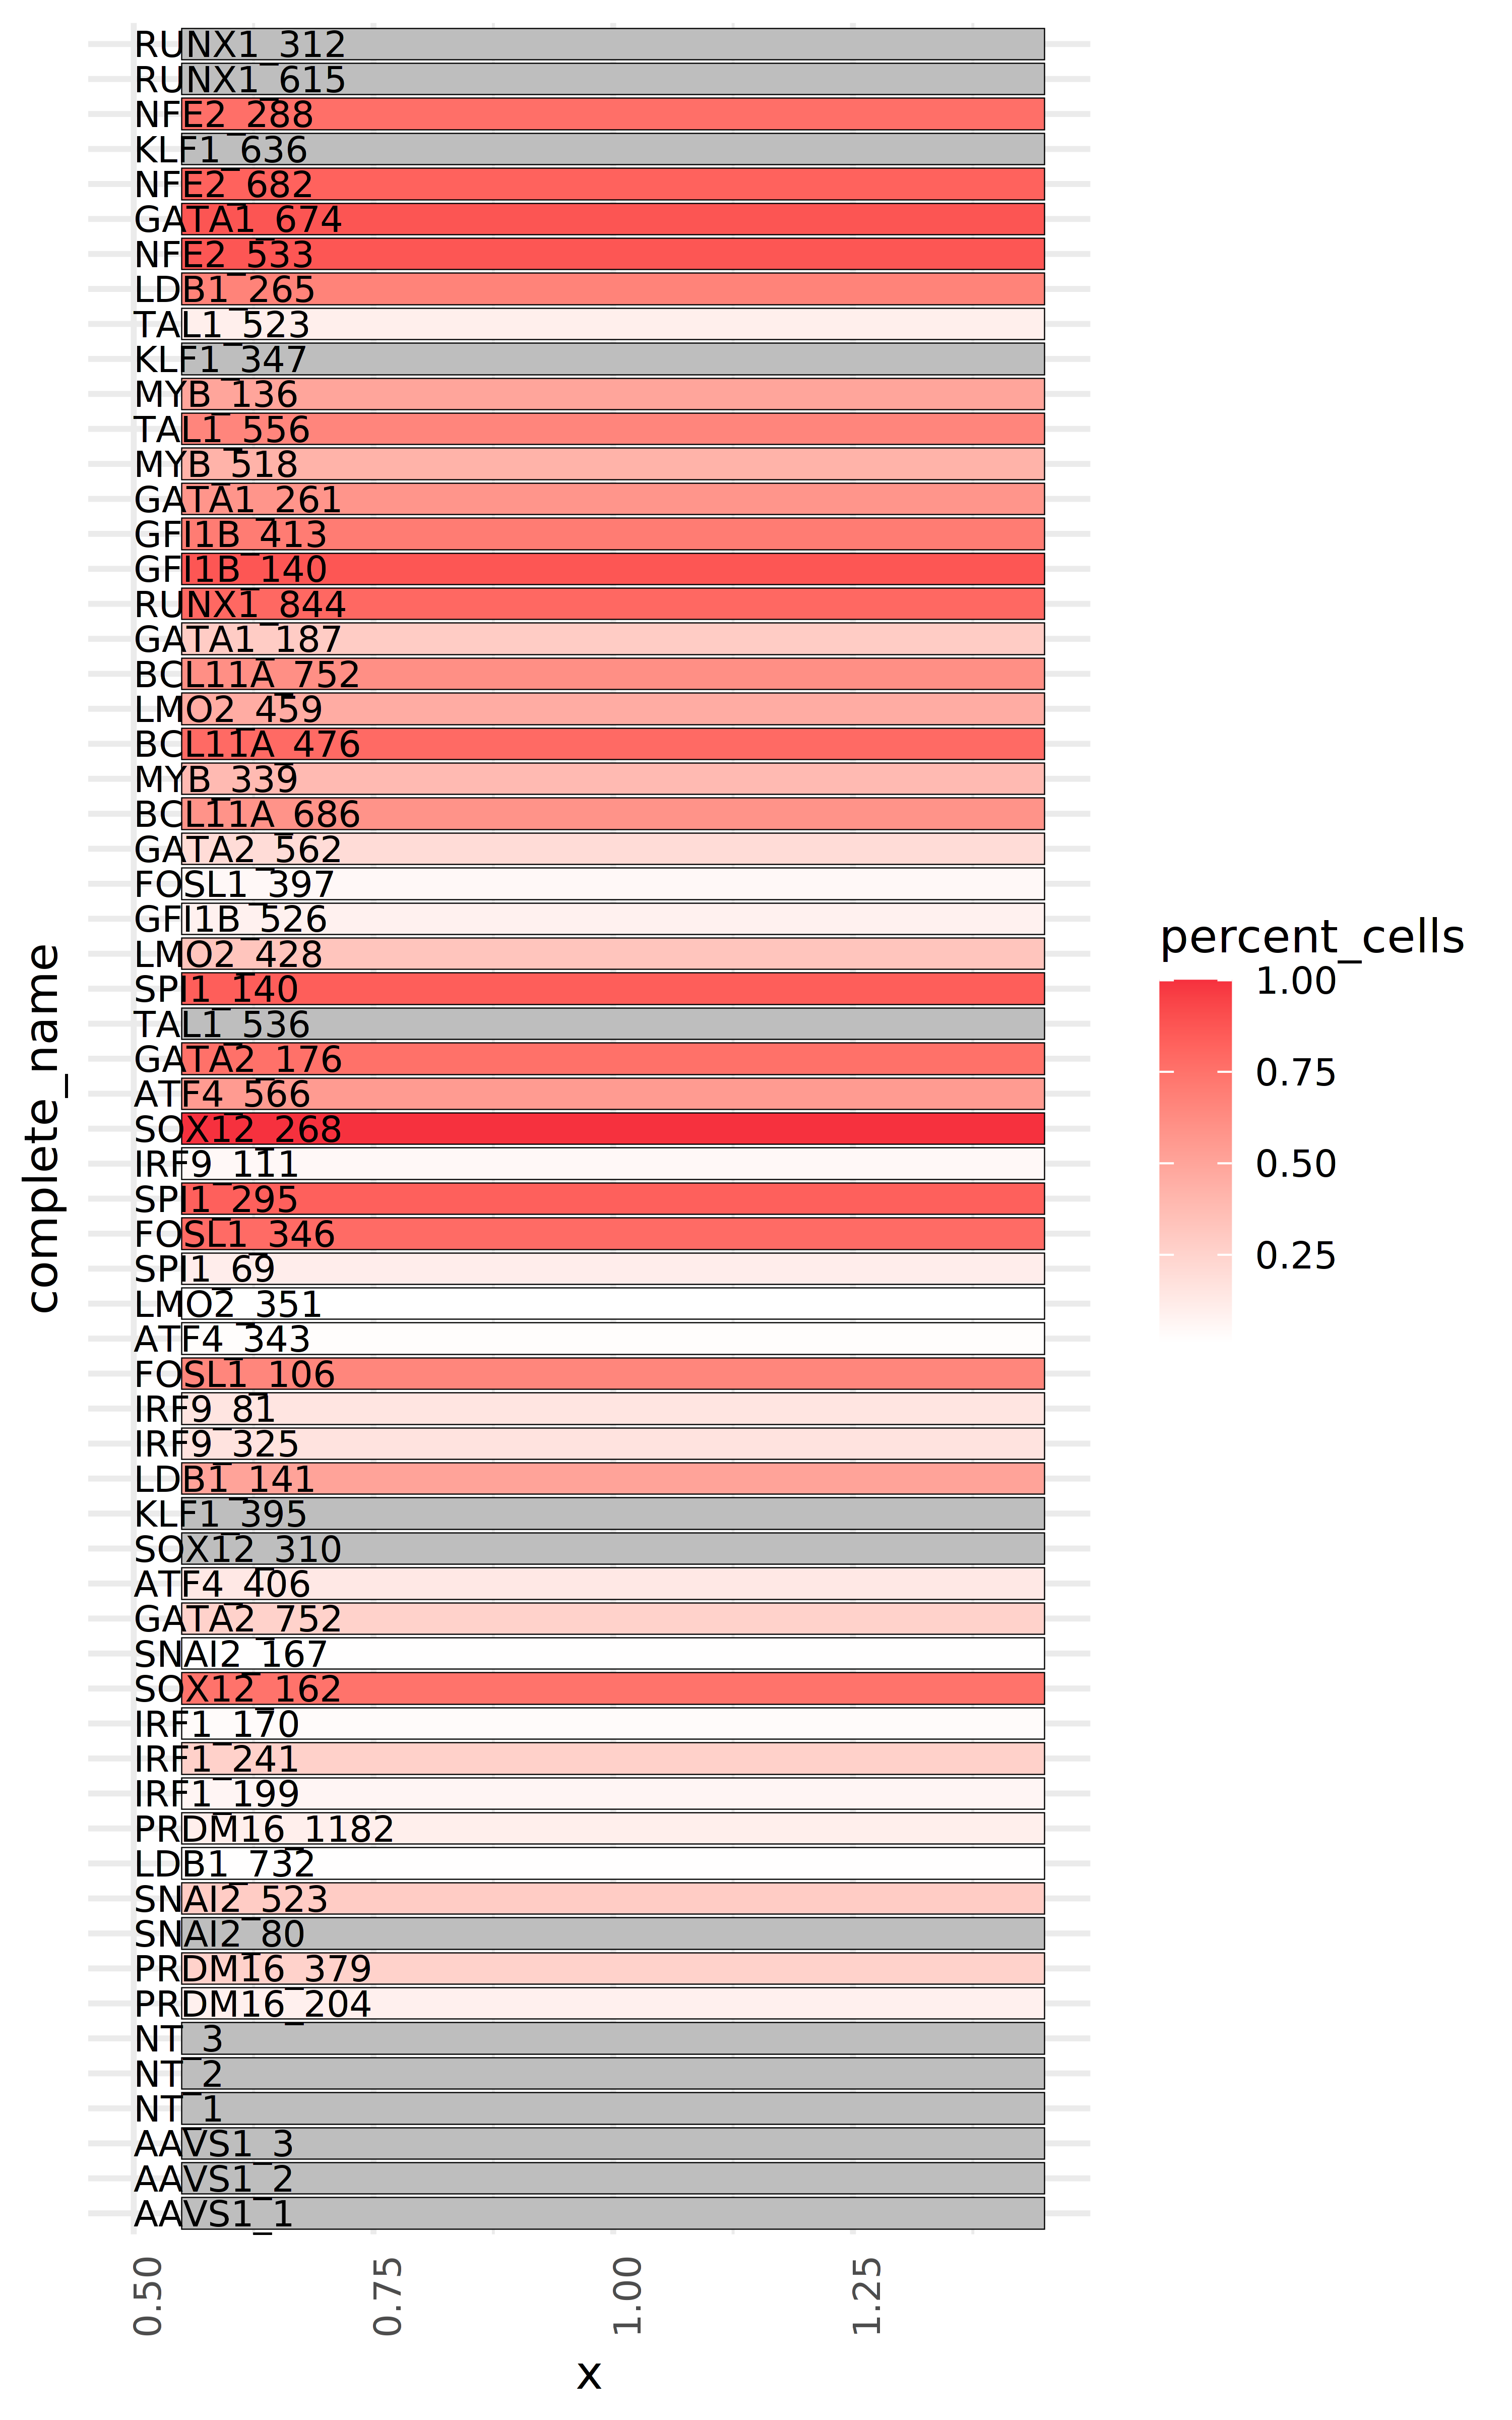

In [94]:
figure_name='JAN_028_032_RNA_score_editing_efficiency_single_color.pdf'
width=5
height=8
options(repr.plot.width = width, repr.plot.height = height, repr.plot.res = 600)

library(ggplot2)
library(BuenColors)

complete_names <- unique(data_efficiencies$perturbation_name_sorted)  # Unique names from the original plot
data_efficiencies_extended <- data.frame(complete_name = complete_names)

data_efficiencies_full <- merge(data.frame(complete_name = ordered_names_RNA), data_efficiencies, by = "complete_name", all.x = TRUE)

data_efficiencies_full$complete_name <- factor(data_efficiencies_full$complete_name, levels = ordered_names_RNA)

square_plot <- ggplot(data_efficiencies_full, aes(y = complete_name, x = 1, fill = percent_cells)) + 
  geom_tile(color = "black", width = 0.9, height = 0.9) +  
  scale_fill_gradient(low = "white", high = jdb_color_map(c("MEP")), na.value = "grey") + 
  theme_minimal() +
  theme(axis.text.x = element_text(angle = 90, hjust = 1), axis.ticks.y = element_blank(), axis.text.y = element_blank()) +
  geom_text(aes(y = complete_name, x = 0.5, label = complete_name), hjust = 0, color = "black", size = 3)

square_plot

#ggsave(paste(output_folder,figure_name,sep=""),dpi = 600, width = width, height = height)


Load files

In [1]:
JAN_028_combined_filtered=readRDS("~/github_reproducibility/merged_seurat_object_step2_all_reps.RDS")

perturbed_tfs=unique(JAN_028_combined_filtered@meta.data$target)



In [31]:
#seurat_obj_mixscale_separate_guides_AAVS1_1_reference_ATAC=readRDS("~/github_reproducibility/merged_seurat_object_step2_all_reps_with_LSI.RDS")



Remove the two replicates that had wetting failures:

In [33]:
library(dplyr)
JAN_028_combined_filtered=JAN_028_combined_filtered[,colnames(seurat_obj_mixscale_separate_guides_AAVS1_1_reference_ATAC)]

Process the Seurat object

In [35]:
library(Seurat)
DefaultAssay(JAN_028_combined_filtered)='RNA'
JAN_028_combined_filtered <- NormalizeData(JAN_028_combined_filtered)
JAN_028_combined_filtered <- FindVariableFeatures(JAN_028_combined_filtered, selection.method = "vst", nfeatures = 2000)
JAN_028_combined_filtered <- ScaleData(JAN_028_combined_filtered, features = VariableFeatures(object = JAN_028_combined_filtered))
JAN_028_combined_filtered <- RunPCA(JAN_028_combined_filtered, features = VariableFeatures(object = JAN_028_combined_filtered))

JAN_028_combined_filtered <- FindNeighbors(object = JAN_028_combined_filtered, dims = 1:30)
JAN_028_combined_filtered <- FindClusters(object = JAN_028_combined_filtered, verbose = FALSE, resolution=0.5)

JAN_028_combined_filtered <- RunUMAP(object = JAN_028_combined_filtered, reduction = 'pca', dims = 1:30)


Centering and scaling data matrix

PC_ 1 
Positive:  SLC25A37, HBA1, SLC4A1, HBA2, SOX6, GYPB, GYPA, HBM, HEMGN, SNCA 
	   RHCE, LGALS3, CR1L, AC107223.1, TSPAN5, HBD, CPEB4, GYPE, JAZF1, CD36 
	   AC024267.1, CA2, AC079804.3, H1F0, HBG1, HIST1H1C, HMGB2, ESR2, TSPO2, ISG20 
Negative:  SLC24A3, CELF2, TNIK, RUNX1, LRMDA, RNF130, STXBP5, ELMO1, SRGN, GAB2 
	   HDC, DOCK8, AL034397.3, VAV3, MAML3, ETV6, MCTP1, DOCK2, FNDC3B, PTPRC 
	   FLI1, GATA2, ITPR2, IL18R1, PKM, GCSAML, PHACTR2, ENPP3, UTRN, TPM4 
PC_ 2 
Positive:  CDK6, MTSS1, CMSS1, NCL, PVT1, STON2, HSP90AB1, GPHN, THRB, SOS1 
	   SCFD2, XACT, FHIT, SNHG3, CCSER1, ACACA, KIT, FIRRE, ZDHHC14, CPQ 
	   ELOVL6, HDAC7, OSBPL6, SPATA5, DDX10, NPM1, CPED1, HSP90AA1, ADAMTS3, TMEM117 
Negative:  CR1, FRY, HBA2, HBA1, HBD, LIN7A, IKZF2, CPA3, TMEM154, AC093865.1 
	   RFX8, HDC, HBM, BCL2, THSD7A, CDK15, AKAP12, MYO1F, RASGRP3, LPCAT2 
	   SLC45A3, ATP10D, RCSD1, ANKRD44, DACH1, PIK3R6, TTLL7, XYLT1, PLCL2, RHEX 
PC_ 3 
Positive:  NPM1, 

In [36]:
JAN_028_combined_filtered$gene=JAN_028_combined_filtered$target

In [37]:
seurat_obj=JAN_028_combined_filtered

In [38]:
Idents(seurat_obj)='gene'

In [50]:
saveRDS(seurat_obj,"~/github_reproducibility/merged_seurat_object_step2_with_umap.RDS")

# TF-sensitive gene (RNA) computation

In [40]:
#seurat_obj_RNA=readRDS("~/github_reproducibility/merged_seurat_object_step2_with_umap.RDS")

In [41]:
seurat_obj_RNA=seurat_obj

In [42]:
seurat_obj_RNA=FindVariableFeatures(seurat_obj_RNA)



In [43]:
seurat_obj_RNA@meta.data$guide_ID=seurat_obj_RNA@meta.data$perturbation_name

In [44]:
seurat_obj_mixscale_separate_guides_AAVS1_1_reference_RNA <- CalcPerturbSig(
    object = seurat_obj_RNA, 
    assay = "RNA", 
    slot = "data", 
    gd.class ="guide_ID", 
    nt.cell.class = "AAVS1_1", 
    reduction = "pca", 
    ndims = 30, 
    num.neighbors = 20, 
    new.assay.name = "PRTB")

Processing rep1

Warning message in asMethod(object):
“sparse->dense coercion: allocating vector of size 2.1 GiB”


In [45]:
seurat_obj_mixscale_separate_guides_AAVS1_1_reference_RNA=ScaleData(seurat_obj_mixscale_separate_guides_AAVS1_1_reference_RNA)


Centering and scaling data matrix



In [46]:
#detach("package:Mixscale", unload=TRUE)


In [47]:
devtools::install_github("longmanz/Mixscale")


Skipping install of 'Mixscale' from a github remote, the SHA1 (4f280022) has not changed since last install.
  Use `force = TRUE` to force installation



In [48]:
library(Mixscale)

In [49]:
# Mixscale
seurat_obj_mixscale_separate_guides_AAVS1_1_reference_RNA = RunMixscale(
    object = seurat_obj_mixscale_separate_guides_AAVS1_1_reference_RNA, 
    assay = "PRTB", 
    slot = "scale.data", 
    labels = "gene", 
    nt.class.name = "NT", 
    min.de.genes = 0, 
    logfc.threshold = 0,
    de.assay = "RNA",
    max.de.genes = 100, 
    new.class.name = "mixscale_score", 
    fine.mode = TRUE, 
    verbose = TRUE)

Calculating Mixscale scores ...

Warning message in RunMixscale(object = seurat_obj_mixscale_separate_guides_AAVS1_1_reference_RNA, :
“The min.de.genes should be larger than 1!”
Processing KLF1

Finding new perturbation gene set

Finding new perturbation gene set

Finding new perturbation gene set

The number of de.genes ( 899 ) is larger than max.de.genes ( 100 ). Restricting to top 100 genes...

Done with extracting top DE genes for KLF1

Processing TAL1

Finding new perturbation gene set

Finding new perturbation gene set

Finding new perturbation gene set

The number of de.genes ( 3036 ) is larger than max.de.genes ( 100 ). Restricting to top 100 genes...

Done with extracting top DE genes for TAL1

Processing MYB

Finding new perturbation gene set

Finding new perturbation gene set

Finding new perturbation gene set

The number of de.genes ( 1200 ) is larger than max.de.genes ( 100 ). Restricting to top 100 genes...

Done with extracting top DE genes for MYB

Processing PRDM16

Fi

Calculating the overall PRTB score...


Done calculating LOO PRTB score for 100 genes in con1...


  TAL1



Calculating the overall PRTB score...


Done calculating LOO PRTB score for 100 genes in con1...


  MYB



Calculating the overall PRTB score...


Done calculating LOO PRTB score for 100 genes in con1...


  PRDM16



Calculating the overall PRTB score...


Done calculating LOO PRTB score for 1 genes in con1...


  IRF9



Calculating the overall PRTB score...


Done calculating LOO PRTB score for 100 genes in con1...


  FOSL1



Calculating the overall PRTB score...


Done calculating LOO PRTB score for 100 genes in con1...


  GATA1



Calculating the overall PRTB score...


Done calculating LOO PRTB score for 100 genes in con1...


  LMO2



Calculating the overall PRTB score...


Done calculating LOO PRTB score for 100 genes in con1...


  GFI1B



Calculating the overall PRTB score...


Done calculating LOO PRTB score for 100 genes in con1...


  IRF1



Calculating the overall PRTB score...


Done calculating LOO PRTB score for 7 genes in con1...


  BCL11A



Calculating the overall PRTB score...


Done calculating LOO PRTB score for 100 genes in con1...


  LDB1



Calculating the overall PRTB score...


Done calculating LOO PRTB score for 100 genes in con1...


  RUNX1



Calculating the overall PRTB score...


Done calculating LOO PRTB score for 100 genes in con1...


  ATF4



Calculating the overall PRTB score...


Done calculating LOO PRTB score for 51 genes in con1...


  NFE2



Calculating the overall PRTB score...


Done calculating LOO PRTB score for 100 genes in con1...


  SNAI2



Calculating the overall PRTB score...


Done calculating LOO PRTB score for 34 genes in con1...


  SPI1



Calculating the overall PRTB score...


Done calculating LOO PRTB score for 100 genes in con1...


  SOX12



Calculating the overall PRTB score...


Done calculating LOO PRTB score for 67 genes in con1...


  GATA2



Calculating the overall PRTB score...


Done calculating LOO PRTB score for 100 genes in con1...


Done with calculating scores for con1



Figure 2A, for RNA:

In [55]:
figure_name="JAN_028_mixscale_score_RNA.pdf"
width = 9.28
height = 40
options(repr.plot.width = width, repr.plot.height = height, repr.plot.res = 600)

library(ggridges)
library(ggplot2)
library(viridis)
library(dplyr)  

data <- seurat_obj_mixscale_separate_guides_AAVS1_1_reference_RNA@meta.data

special_groups <- c("AAVS1_1", "AAVS1_2", "AAVS1_3", "NT_1", "NT_2", "NT_3")

regular_data <- data[!data$perturbation_name %in% special_groups, ]

average_scores <- regular_data %>%
  group_by(perturbation_name) %>%
  summarize(average_score = mean(mixscale_score, na.rm = TRUE)) %>%
  ungroup() %>%
  arrange(average_score) 

color_values <- viridis(n = nrow(average_scores))
color_values[average_scores$average_score == 0] <- "#440154FF"  

colors <- setNames(color_values, average_scores$perturbation_name)
colors[special_groups] <- "grey"

data$color_group <- ifelse(data$perturbation_name %in% special_groups, "Special", as.character(data$perturbation_name))

ordered_names <- c(special_groups, average_scores$perturbation_name)
ordered_names_RNA=c('AAVS1_1','AAVS1_2','AAVS1_3','NT_1','NT_2','NT_3','PRDM16_204','PRDM16_379','SNAI2_80','SNAI2_523','LDB1_732','PRDM16_1182','IRF1_199','IRF1_241','IRF1_170','SOX12_162','SNAI2_167','GATA2_752','ATF4_406','SOX12_310','KLF1_395','LDB1_141','IRF9_325','IRF9_81','FOSL1_106','ATF4_343','LMO2_351','SPI1_69','FOSL1_346','SPI1_295','IRF9_111','SOX12_268','ATF4_566','GATA2_176','TAL1_536','SPI1_140','LMO2_428','GFI1B_526','FOSL1_397','GATA2_562','BCL11A_686','MYB_339','BCL11A_476','LMO2_459','BCL11A_752','GATA1_187','RUNX1_844','GFI1B_140','GFI1B_413','GATA1_261','MYB_518','TAL1_556','MYB_136','KLF1_347','TAL1_523','LDB1_265','NFE2_533','GATA1_674','NFE2_682','KLF1_636','NFE2_288','RUNX1_615','RUNX1_312')
data$perturbation_name_sorted <- factor(data$perturbation_name, levels = ordered_names_RNA)

ggplot(data, aes(x = mixscale_score, y = perturbation_name_sorted, fill = color_group)) +
  geom_density_ridges(alpha = 0.8, scale = 3) +
  scale_fill_manual(values = colors) +
  theme(
    legend.position = "none",
    panel.spacing = unit(0.1, "lines"),
    strip.text.x = element_text(size = 8)
  )+
  theme_minimal() +
  theme(
    text = element_text(size = 16),
    axis.title.y = element_blank(),
          axis.title.x = element_text(size = 22,margin = unit(c(0, 4, 0, 0), "mm")),
      axis.ticks = element_line(size = .6),
      axis.ticks.length=unit(0.06,"inch"),
    axis.text.x = element_text(angle = 0, hjust = 0.5, vjust = 0, size = 22,color='black'),
    axis.text.y = element_text(size = 22,color='black'),
    panel.background = element_blank(),
    panel.grid.major = element_blank(),
    panel.grid.minor = element_blank(),
    axis.line = element_line(color = "black",size = .6),
    strip.text = element_text(size = 16),
      legend.key.size = unit(1, 'cm'),
      legend.text=element_text(size=22),
      legend.title=element_text(size=22),
    strip.background = element_blank()
  )+ theme(legend.position="none")+xlim(-2.5,6)

p = ggplot(data, aes(x = mixscale_score, y = perturbation_name_sorted, fill = color_group)) +
  geom_density_ridges(alpha = 0.8, scale = 3) +
  scale_fill_manual(values = colors) +
  theme(
    legend.position = "none",
    panel.spacing = unit(0.1, "lines"),
    strip.text.x = element_text(size = 8)
  )+
  theme_minimal() +
  theme(
    text = element_text(size = 16),
    axis.title.y = element_blank(),
          axis.title.x = element_text(size = 22,margin = unit(c(0, 4, 0, 0), "mm")),
      axis.ticks = element_line(size = .6),
      axis.ticks.length=unit(0.06,"inch"),
    axis.text.x = element_text(angle = 0, hjust = 0.5, vjust = 0, size = 22,color='black'),
    axis.text.y = element_text(size = 22,color='black'),
    panel.background = element_blank(),
    panel.grid.major = element_blank(),
    panel.grid.minor = element_blank(),
    axis.line = element_line(color = "black",size = .6),
    strip.text = element_text(size = 16),
      legend.key.size = unit(1, 'cm'),
      legend.text=element_text(size=22),
      legend.title=element_text(size=22),
    strip.background = element_blank()
  )+ theme(legend.position="none")+xlim(-2.5,6)

#ggsave(paste(output_folder,figure_name,sep=""),dpi = 600, width = width, height = height)


Picking joint bandwidth of 0.197

Warning message:
“Removed 890 rows containing non-finite outside the scale range
(`stat_density_ridges()`).”


In [52]:
seurat_obj_mixscale_separate_guides_AAVS1_1_reference_RNA@meta.data$perturbation_name=
seurat_obj_mixscale_separate_guides_AAVS1_1_reference_RNA@meta.data$guide_ID

In [53]:
seurat_obj_mixscale_separate_guides_AAVS1_1_reference_RNA@meta.data$nCount_RNA=
colSums(seurat_obj_mixscale_separate_guides_AAVS1_1_reference_RNA@assays$RNA@counts)

In [57]:
saveRDS(seurat_obj_mixscale_separate_guides_AAVS1_1_reference_RNA,"~/github_reproducibility/seurat_obj_mixscale_separate_guides_AAVS1_1_reference_RNA.RDS")

In [ ]:
#write.table(seurat_obj_mixscale_separate_guides_AAVS1_1_reference_RNA_metadata,"JAN_028_seurat_obj_mixscale_separate_guides_AAVS1_1_reference_RNA.csv")
#write.table(seurat_obj_mixscale_separate_guides_AAVS1_1_reference_ATAC_metadata,"JAN_028_seurat_obj_mixscale_separate_guides_AAVS1_1_reference_ATAC.csv")



Copy Seurat object to Google bucket and proceed to run the WDL to execute mixscale_script_only_final_step_for_Terra_WDL.R using terra.bio